# Event Study — Impacto de Publicaciones Macroeconómicas en la Volatilidad del IBEX 35

**TFG:** Impacto de las variables macroeconómicas en la volatilidad del IBEX 35

---

## Motivación

En el Capítulo 1 (modelos predictivos) hemos demostrado que los **niveles** de las variables macroeconómicas no mejoran sustancialmente la predicción de volatilidad frente al simple lag de volatilidad (R² pasa de ~0.97 a ~0.97x). La persistencia domina.

Sin embargo, esto no significa que las variables macro sean irrelevantes. La pregunta correcta no es *"¿predicen los niveles macro la volatilidad futura?"*, sino **"¿generan las publicaciones macro shocks puntuales de volatilidad?"**.

Este notebook responde esa pregunta mediante un **event study**: identificamos los días de publicación de cada indicador macroeconómico y medimos si la volatilidad del IBEX 35 ese día es significativamente mayor que en días normales.

### Metodología

1. **Identificación de eventos**: un evento ocurre el día en que un indicador macro cambia de valor respecto al día anterior (Δmacro ≠ 0)
2. **Medida de volatilidad diaria**: usamos |log_ret| (retorno absoluto diario) como proxy — a diferencia de vol_hist_21d (media 21d), captura el shock puntual
3. **Volatilidad anormal**: comparamos |log_ret| del día del evento contra la mediana de la ventana [-10, -1] (benchmark)
4. **Tests estadísticos**: Wilcoxon signed-rank (¿la vol anormal es significativamente > 0?) y Kruskal-Wallis (¿difiere entre tipos de publicación?)
5. **Análisis por signo de la sorpresa**: ¿importa si el dato mejora o empeora?

## 0. Configuración e importaciones

In [1]:
import os
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, kruskal, mannwhitneyu

warnings.filterwarnings('ignore')

# ── Estilo ────────────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
sns.set_style('whitegrid')
COLORS = sns.color_palette('deep')
SEED   = 42

# ── Rutas ─────────────────────────────────────────────────────────────────────
BASE    = os.path.expanduser(
    '~/Library/Mobile Documents/com~apple~CloudDocs/'
    'UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4\u00ba/TFG')
DB_PATH = os.path.join(BASE, 'proyecto', 'data', 'db', 'tfg.db')
FIG_DIR = os.path.join(BASE, 'proyecto', 'outputs', 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'DB    : {DB_PATH}')
print(f'Figs  : {FIG_DIR}')

DB    : /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/data/db/tfg.db
Figs  : /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/outputs/figuras


## 1. Carga de datos y construcción de la serie IBEX agregada

In [2]:
# ── Carga del dataset maestro ─────────────────────────────────────────────────
with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql('SELECT * FROM dataset_maestro', conn, parse_dates=['fecha'])

df_raw = df_raw.sort_values(['ticker', 'fecha']).reset_index(drop=True)

# ── Serie agregada IBEX (media diaria de todos los tickers) ───────────────────
ibex = df_raw.groupby('fecha').agg(
    abs_ret=('log_ret', lambda x: np.abs(x).mean()),   # proxy vol diaria
    log_ret=('log_ret', 'mean'),
    vol_21d=('vol_hist_21d', 'mean'),
).sort_index()

# ── Variables macro (una obs por fecha, forward-filled en dataset_maestro) ────
MACRO_EVENT_COLS = {
    # nombre_columna: (nombre_legible, categoría)
    'ipc_yoy':     ('IPC interanual',          'Inflación'),
    'ipc_sub_mom': ('IPC subyacente mensual',   'Inflación'),
    'pib_yoy':     ('PIB interanual',           'Actividad real'),
    'tasa_paro':   ('Tasa de paro',             'Actividad real'),
    'ipi_yoy':     ('Producción industrial',    'Actividad real'),
    'euribor_3m':  ('Euríbor 3M',               'Política monetaria'),
    'tipo_dfr':    ('Tipo BCE (DFR)',            'Política monetaria'),
}

macro = (df_raw.drop_duplicates('fecha')
         .sort_values('fecha')
         .set_index('fecha')[list(MACRO_EVENT_COLS.keys())])

# Merge
df = ibex.join(macro).sort_index()

print(f'Periodo: {df.index.min().date()} → {df.index.max().date()}')
print(f'Días de negociación: {len(df):,}')
print(f'Variables macro para event study: {len(MACRO_EVENT_COLS)}')

Periodo: 2005-01-03 → 2025-10-31
Días de negociación: 5,323
Variables macro para event study: 7


## 2. Identificación de eventos macroeconómicos

Un **evento** se define como el primer día de negociación en el que un indicador macro toma un valor distinto al del día anterior. Al estar los datos forward-filled en `dataset_maestro`, esto equivale a la fecha de publicación (o el primer día hábil posterior).

In [3]:
# ── Detectar días de publicación (cambio en el valor) ─────────────────────────
events = []

for col, (nombre, categoria) in MACRO_EVENT_COLS.items():
    serie = df[col].dropna()
    cambio = serie.diff().fillna(0)
    fechas_evento = cambio[cambio != 0].index

    for fecha in fechas_evento:
        delta = cambio.loc[fecha]
        valor_nuevo = serie.loc[fecha]
        events.append({
            'fecha': fecha,
            'variable': col,
            'nombre': nombre,
            'categoria': categoria,
            'delta': delta,
            'valor_nuevo': valor_nuevo,
            'signo': 'Positivo' if delta > 0 else 'Negativo',
        })

df_events = pd.DataFrame(events)
df_events['fecha'] = pd.to_datetime(df_events['fecha'])

print(f'Total eventos identificados: {len(df_events)}')
print()
print('Eventos por variable:')
print(df_events.groupby(['categoria', 'nombre']).size()
      .reset_index(name='n_eventos')
      .sort_values('n_eventos', ascending=False)
      .to_string(index=False))
print()
print('Eventos por categoría:')
print(df_events.groupby('categoria').size().to_string())

Total eventos identificados: 1058

Eventos por variable:
         categoria                 nombre  n_eventos
    Actividad real  Producción industrial        248
Política monetaria             Euríbor 3M        246
         Inflación IPC subyacente mensual        236
         Inflación         IPC interanual        145
    Actividad real           Tasa de paro         81
    Actividad real         PIB interanual         69
Política monetaria         Tipo BCE (DFR)         33

Eventos por categoría:
categoria
Actividad real        398
Inflación             381
Política monetaria    279


## 3. Cálculo de volatilidad anormal

Para cada evento, medimos:

- **Vol del evento**: |log_ret| del día de publicación
- **Vol benchmark**: mediana de |log_ret| en la ventana [-10, -1] días (10 días hábiles anteriores)
- **Vol anormal** = Vol evento − Vol benchmark
- **Vol anormal relativa** = (Vol evento − Vol benchmark) / Vol benchmark

Usamos la mediana (no la media) como benchmark para evitar que un outlier previo distorsione la referencia.

In [4]:
# ── Calcular volatilidad anormal para cada evento ─────────────────────────────
WINDOW_PRE = 10  # días hábiles antes del evento como benchmark

vol_evento = []
vol_benchmark = []
vol_anormal = []
vol_anormal_rel = []
vol_post_1d = []   # día siguiente al evento
vol_post_2d = []   # 2 días después
valid_mask = []

abs_ret_series = df['abs_ret']
dates_index = df.index

for _, row in df_events.iterrows():
    fecha = row['fecha']
    if fecha not in dates_index:
        valid_mask.append(False)
        vol_evento.append(np.nan)
        vol_benchmark.append(np.nan)
        vol_anormal.append(np.nan)
        vol_anormal_rel.append(np.nan)
        vol_post_1d.append(np.nan)
        vol_post_2d.append(np.nan)
        continue

    pos = dates_index.get_loc(fecha)

    # Benchmark: mediana de |log_ret| en [-10, -1]
    if pos < WINDOW_PRE:
        valid_mask.append(False)
        vol_evento.append(np.nan)
        vol_benchmark.append(np.nan)
        vol_anormal.append(np.nan)
        vol_anormal_rel.append(np.nan)
        vol_post_1d.append(np.nan)
        vol_post_2d.append(np.nan)
        continue

    window = abs_ret_series.iloc[pos - WINDOW_PRE : pos]
    bm = window.median()
    ve = abs_ret_series.iloc[pos]

    # Post-evento
    vp1 = abs_ret_series.iloc[pos + 1] if pos + 1 < len(dates_index) else np.nan
    vp2 = abs_ret_series.iloc[pos + 2] if pos + 2 < len(dates_index) else np.nan

    vol_evento.append(ve)
    vol_benchmark.append(bm)
    vol_anormal.append(ve - bm)
    vol_anormal_rel.append((ve - bm) / bm if bm > 0 else np.nan)
    vol_post_1d.append(vp1)
    vol_post_2d.append(vp2)
    valid_mask.append(True)

df_events['vol_evento'] = vol_evento
df_events['vol_benchmark'] = vol_benchmark
df_events['vol_anormal'] = vol_anormal
df_events['vol_anormal_rel'] = vol_anormal_rel
df_events['vol_post_1d'] = vol_post_1d
df_events['vol_post_2d'] = vol_post_2d
df_events['valid'] = valid_mask

# Filtrar eventos válidos
df_ev = df_events[df_events['valid']].copy()

print(f'Eventos válidos (con ventana completa): {len(df_ev)} / {len(df_events)}')
print()
print('Estadísticos de la volatilidad anormal:')
print(f'  Media   : {df_ev["vol_anormal"].mean():.6f}')
print(f'  Mediana : {df_ev["vol_anormal"].median():.6f}')
print(f'  Std     : {df_ev["vol_anormal"].std():.6f}')
print(f'  % positivos: {(df_ev["vol_anormal"] > 0).mean()*100:.1f}%')

Eventos válidos (con ventana completa): 1058 / 1058

Estadísticos de la volatilidad anormal:
  Media   : 0.002411
  Mediana : 0.001691
  Std     : 0.006190
  % positivos: 61.9%


## 4. Figura 20: Panorama general del event study

Visión agregada: ¿generan las publicaciones macro más volatilidad que un día normal?

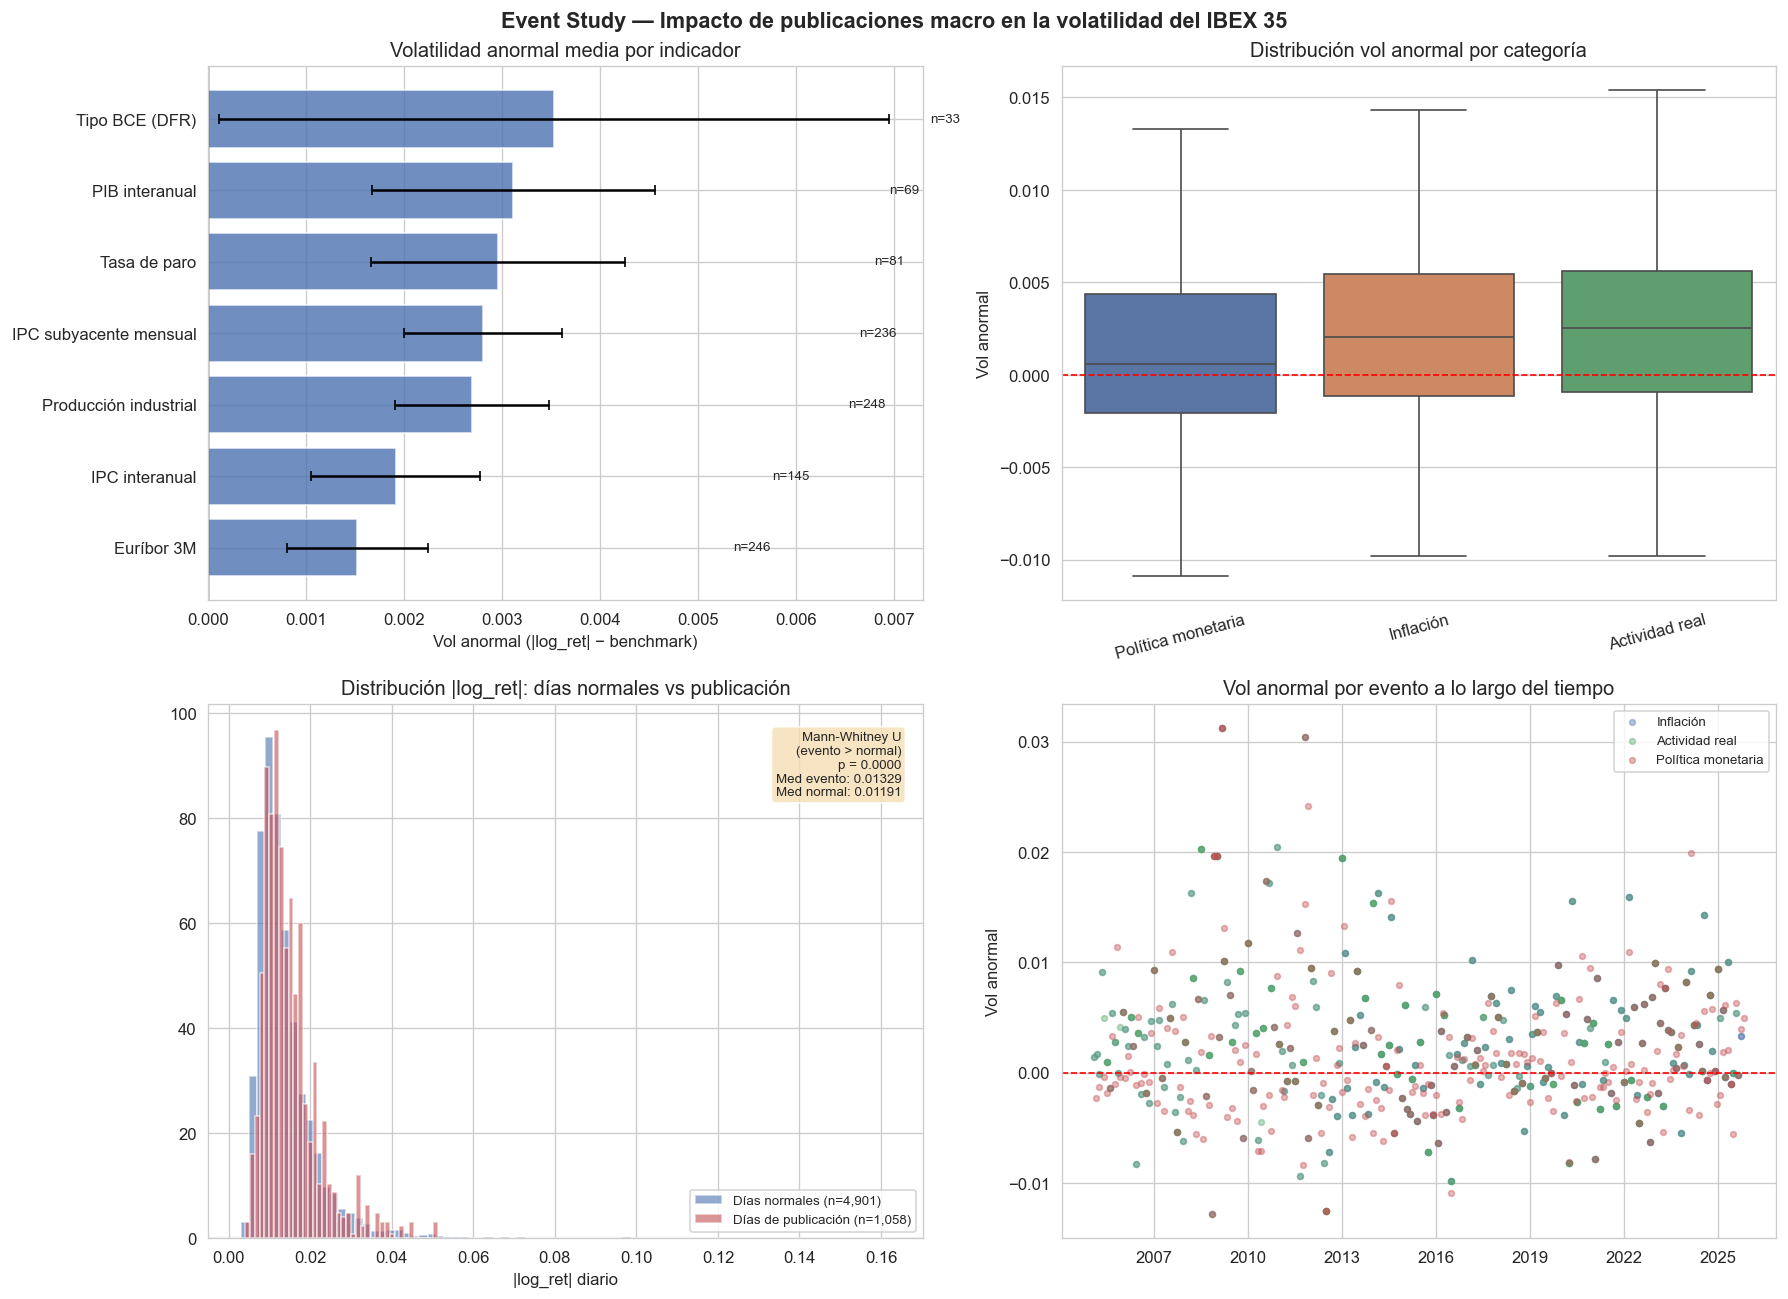

Figura guardada: 20_event_study_panorama.png


In [5]:
# ── Figura 20: Panorama general ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Event Study — Impacto de publicaciones macro en la volatilidad del IBEX 35',
             fontsize=13, fontweight='bold')

# ── P1: Vol anormal media por variable ─────────────────────────────────────────
ax = axes[0, 0]
resumen = (df_ev.groupby('nombre')['vol_anormal']
           .agg(['mean', 'median', 'count', 'std'])
           .sort_values('mean', ascending=True))
resumen['se'] = resumen['std'] / np.sqrt(resumen['count'])
colors_bar = [COLORS[0] if v > 0 else COLORS[3] for v in resumen['mean']]
ax.barh(resumen.index, resumen['mean'], xerr=resumen['se'] * 1.96,
        color=colors_bar, capsize=3, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Volatilidad anormal media por indicador')
ax.set_xlabel('Vol anormal (|log_ret| − benchmark)')
for i, (idx, row) in enumerate(resumen.iterrows()):
    ax.text(row['mean'] + resumen['se'].max() * 2.2 * np.sign(row['mean']),
            i, f'n={int(row["count"])}', va='center', fontsize=8)

# ── P2: Vol anormal por categoría (boxplot) ───────────────────────────────────
ax = axes[0, 1]
order_cat = df_ev.groupby('categoria')['vol_anormal'].median().sort_values().index
sns.boxplot(data=df_ev, x='categoria', y='vol_anormal', order=order_cat,
            palette='deep', ax=ax, showfliers=False)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_title('Distribución vol anormal por categoría')
ax.set_xlabel('')
ax.set_ylabel('Vol anormal')
ax.tick_params(axis='x', rotation=15)

# ── P3: Distribución vol anormal (eventos vs días normales) ───────────────────
ax = axes[1, 0]
event_dates = set(df_ev['fecha'])
vol_normal = df.loc[~df.index.isin(event_dates), 'abs_ret'].dropna()
vol_event  = df_ev['vol_evento'].dropna()

ax.hist(vol_normal, bins=80, density=True, alpha=0.6, color=COLORS[0],
        label=f'Días normales (n={len(vol_normal):,})')
ax.hist(vol_event, bins=40, density=True, alpha=0.6, color=COLORS[3],
        label=f'Días de publicación (n={len(vol_event):,})')
ax.set_title('Distribución |log_ret|: días normales vs publicación')
ax.set_xlabel('|log_ret| diario')
ax.legend(fontsize=8)

# Test Mann-Whitney
mw_stat, mw_p = mannwhitneyu(vol_event, vol_normal, alternative='greater')
ax.text(0.97, 0.95,
        f'Mann-Whitney U\n(evento > normal)\np = {mw_p:.4f}\n'
        f'Med evento: {vol_event.median():.5f}\n'
        f'Med normal: {vol_normal.median():.5f}',
        transform=ax.transAxes, va='top', ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ── P4: Timeline — vol anormal a lo largo del tiempo ──────────────────────────
ax = axes[1, 1]
for cat, color in zip(['Inflación', 'Actividad real', 'Política monetaria'],
                       [COLORS[0], COLORS[2], COLORS[3]]):
    mask = df_ev['categoria'] == cat
    ax.scatter(df_ev.loc[mask, 'fecha'], df_ev.loc[mask, 'vol_anormal'],
              s=12, alpha=0.4, color=color, label=cat)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_title('Vol anormal por evento a lo largo del tiempo')
ax.set_ylabel('Vol anormal')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '20_event_study_panorama.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 20_event_study_panorama.png')

## 5. Figura 21: Análisis detallado por indicador

Para cada variable macro, analizamos:
- Vol anormal media y su significancia estadística (Wilcoxon)
- ¿Importa el signo del cambio? (¿genera más volatilidad una subida o una bajada del indicador?)
- Persistencia: ¿el efecto dura más de un día?

In [6]:
# ── Tabla resumen con tests estadísticos ──────────────────────────────────────
resultados = []

for col, (nombre, categoria) in MACRO_EVENT_COLS.items():
    sub = df_ev[df_ev['variable'] == col]
    if len(sub) < 5:
        continue

    va = sub['vol_anormal'].dropna()

    # Test Wilcoxon: ¿vol anormal > 0?
    if len(va) >= 10:
        try:
            w_stat, w_p = wilcoxon(va, alternative='greater')
        except ValueError:
            w_stat, w_p = np.nan, np.nan
    else:
        w_stat, w_p = np.nan, np.nan

    # Diferencia por signo
    va_pos = sub.loc[sub['signo'] == 'Positivo', 'vol_anormal']
    va_neg = sub.loc[sub['signo'] == 'Negativo', 'vol_anormal']

    resultados.append({
        'Variable': nombre,
        'Categoría': categoria,
        'N eventos': len(sub),
        'Vol anormal media': va.mean(),
        'Vol anormal mediana': va.median(),
        '% vol > benchmark': (va > 0).mean() * 100,
        'Wilcoxon p': w_p,
        'Significativo (5%)': '✓' if w_p < 0.05 else '✗',
        'VA media (Δ>0)': va_pos.mean() if len(va_pos) > 0 else np.nan,
        'VA media (Δ<0)': va_neg.mean() if len(va_neg) > 0 else np.nan,
        'Vol post 1d': sub['vol_post_1d'].mean(),
        'Vol post 2d': sub['vol_post_2d'].mean(),
    })

df_res = pd.DataFrame(resultados).sort_values('Vol anormal media', ascending=False)

print('=== RESUMEN EVENT STUDY ===')
print()
cols_show = ['Variable', 'Categoría', 'N eventos', 'Vol anormal media',
             '% vol > benchmark', 'Wilcoxon p', 'Significativo (5%)']
print(df_res[cols_show].to_string(index=False, float_format='%.4f'))

print()
print('=== EFECTO POR SIGNO DEL CAMBIO ===')
print()
cols_signo = ['Variable', 'VA media (Δ>0)', 'VA media (Δ<0)']
print(df_res[cols_signo].to_string(index=False, float_format='%.5f'))

print()
print('=== PERSISTENCIA DEL EFECTO ===')
print()
bm_global = df['abs_ret'].median()
print(f'  Benchmark global (mediana |log_ret|): {bm_global:.5f}')
print()
cols_persist = ['Variable', 'Vol post 1d', 'Vol post 2d']
print(df_res[cols_persist].to_string(index=False, float_format='%.5f'))

=== RESUMEN EVENT STUDY ===

              Variable          Categoría  N eventos  Vol anormal media  % vol > benchmark  Wilcoxon p Significativo (5%)
        Tipo BCE (DFR) Política monetaria         33             0.0035            60.6061      0.0584                  ✗
        PIB interanual     Actividad real         69             0.0031            66.6667      0.0000                  ✓
          Tasa de paro     Actividad real         81             0.0030            65.4321      0.0000                  ✓
IPC subyacente mensual          Inflación        236             0.0028            64.8305      0.0000                  ✓
 Producción industrial     Actividad real        248             0.0027            64.9194      0.0000                  ✓
        IPC interanual          Inflación        145             0.0019            60.6897      0.0001                  ✓
            Euríbor 3M Política monetaria        246             0.0015            54.4715      0.0016               

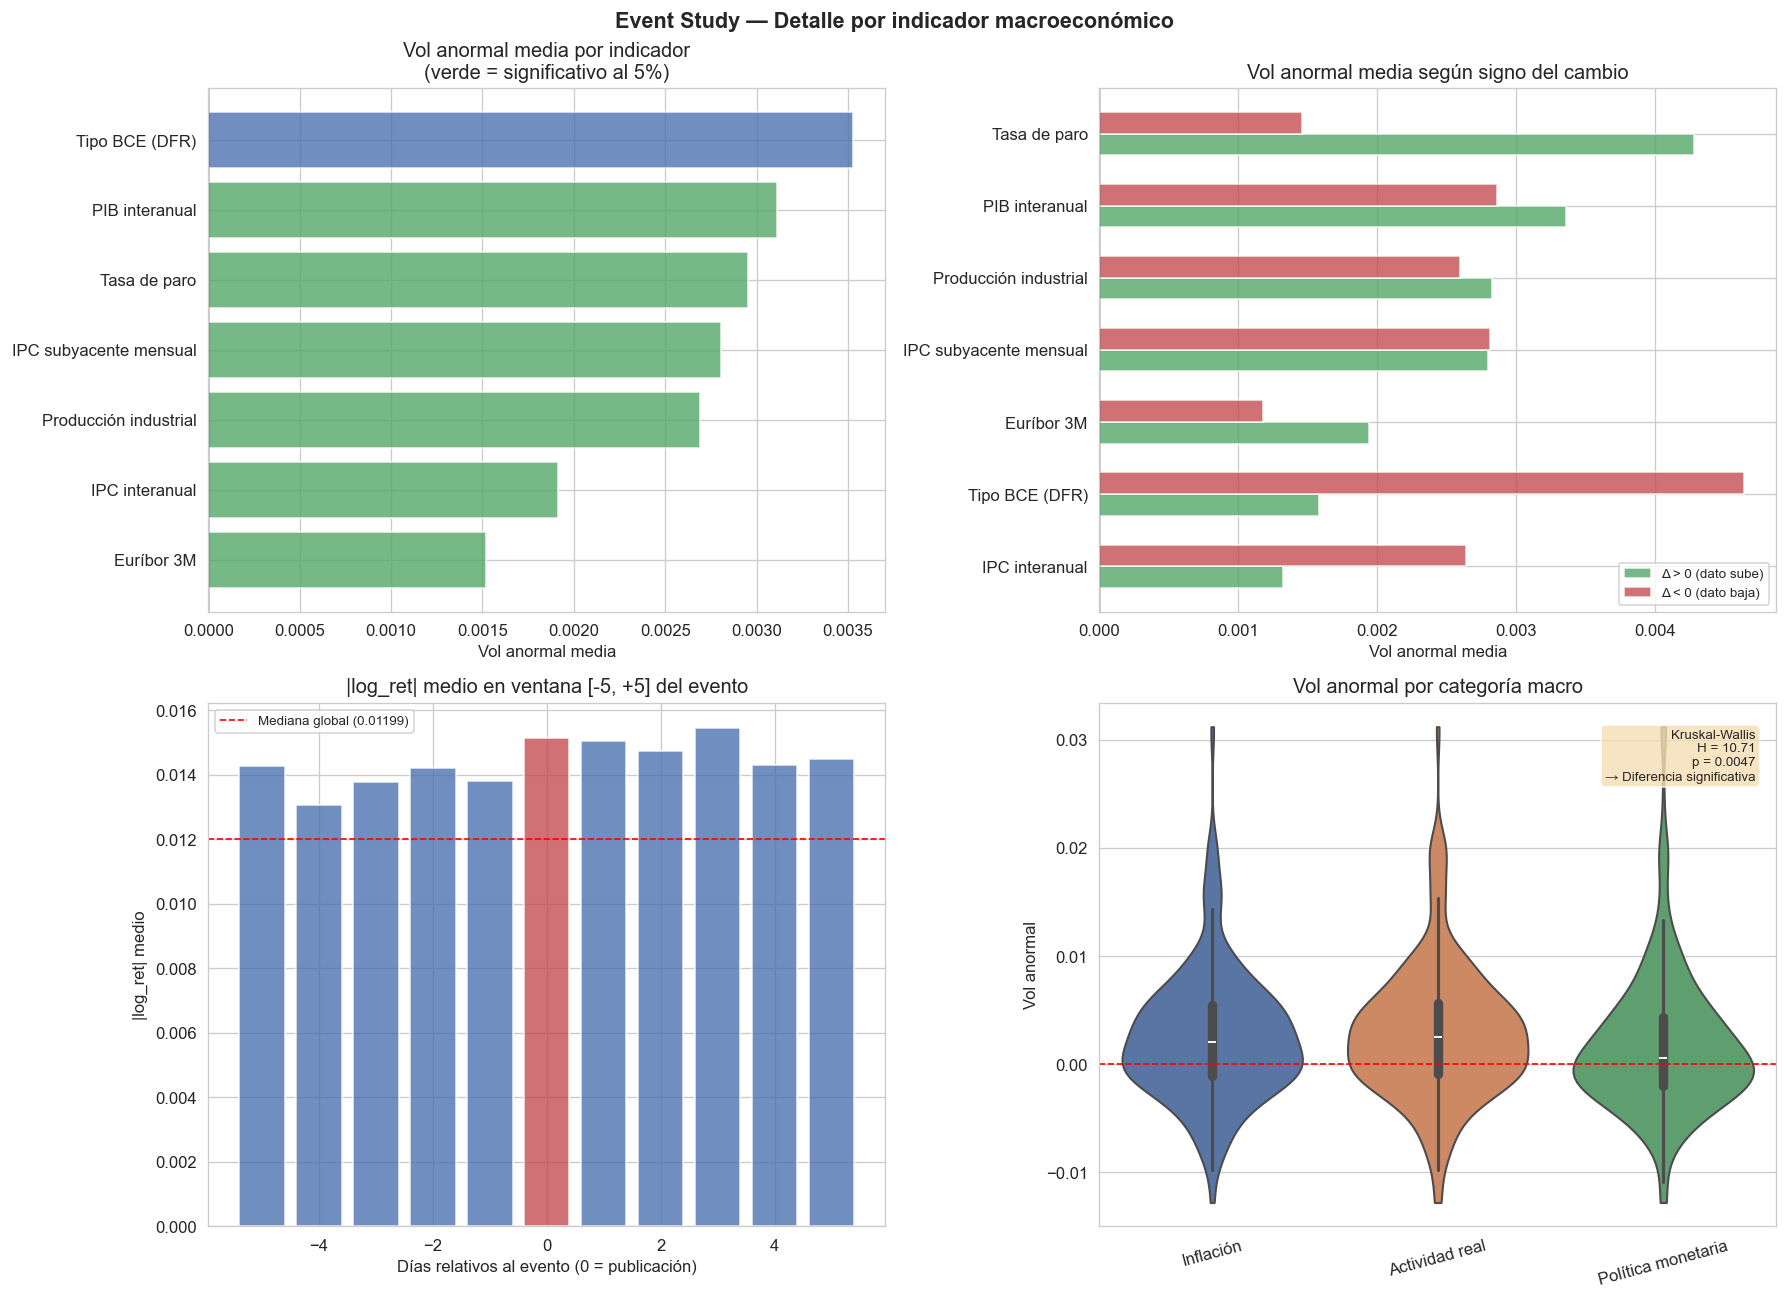

Figura guardada: 21_event_study_detalle.png


In [7]:
# ── Figura 21: Detalle por indicador ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Event Study — Detalle por indicador macroeconómico',
             fontsize=13, fontweight='bold')

# ── P1: Vol anormal media + IC 95% ────────────────────────────────────────────
ax = axes[0, 0]
df_plot = df_res.sort_values('Vol anormal media', ascending=True)
y_pos = range(len(df_plot))
colors_sig = [COLORS[2] if s == '✓' else COLORS[0] for s in df_plot['Significativo (5%)']]
ax.barh(list(y_pos), df_plot['Vol anormal media'], color=colors_sig, alpha=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Variable'])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Vol anormal media por indicador\n(verde = significativo al 5%)')
ax.set_xlabel('Vol anormal media')

# ── P2: Efecto por signo del cambio ───────────────────────────────────────────
ax = axes[0, 1]
df_signo = df_ev.groupby(['nombre', 'signo'])['vol_anormal'].mean().unstack(fill_value=0)
if 'Positivo' in df_signo.columns and 'Negativo' in df_signo.columns:
    df_signo = df_signo.sort_values('Positivo', ascending=True)
    y_pos2 = np.arange(len(df_signo))
    ax.barh(y_pos2 - 0.15, df_signo['Positivo'], height=0.3,
            color=COLORS[2], alpha=0.8, label='Δ > 0 (dato sube)')
    ax.barh(y_pos2 + 0.15, df_signo['Negativo'], height=0.3,
            color=COLORS[3], alpha=0.8, label='Δ < 0 (dato baja)')
    ax.set_yticks(y_pos2)
    ax.set_yticklabels(df_signo.index)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Vol anormal media según signo del cambio')
ax.set_xlabel('Vol anormal media')
ax.legend(fontsize=8)

# ── P3: Ventana temporal [-5, +5] alrededor del evento (agregado) ─────────────
ax = axes[1, 0]
window_range = range(-5, 6)
avg_absret_by_lag = {}
for lag in window_range:
    vals = []
    for _, row in df_ev.iterrows():
        pos = dates_index.get_loc(row['fecha']) if row['fecha'] in dates_index else None
        if pos is not None and 0 <= pos + lag < len(dates_index):
            vals.append(abs_ret_series.iloc[pos + lag])
    avg_absret_by_lag[lag] = np.mean(vals) if vals else np.nan

lags = list(avg_absret_by_lag.keys())
vals_lag = list(avg_absret_by_lag.values())
bar_colors = [COLORS[3] if l == 0 else COLORS[0] for l in lags]
ax.bar(lags, vals_lag, color=bar_colors, alpha=0.8)
ax.axhline(bm_global, color='red', lw=1, ls='--', label=f'Mediana global ({bm_global:.5f})')
ax.set_title('|log_ret| medio en ventana [-5, +5] del evento')
ax.set_xlabel('Días relativos al evento (0 = publicación)')
ax.set_ylabel('|log_ret| medio')
ax.legend(fontsize=8)

# ── P4: Kruskal-Wallis entre categorías ───────────────────────────────────────
ax = axes[1, 1]
groups = [g['vol_anormal'].dropna().values
          for _, g in df_ev.groupby('categoria')]
group_names = [name for name, _ in df_ev.groupby('categoria')]

if len(groups) >= 2 and all(len(g) >= 5 for g in groups):
    kw_stat, kw_p = kruskal(*groups)
else:
    kw_stat, kw_p = np.nan, np.nan

sns.violinplot(data=df_ev, x='categoria', y='vol_anormal',
               palette='deep', ax=ax, inner='box', cut=0)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_title('Vol anormal por categoría macro')
ax.set_xlabel('')
ax.set_ylabel('Vol anormal')
ax.tick_params(axis='x', rotation=15)
ax.text(0.97, 0.95,
        f'Kruskal-Wallis\nH = {kw_stat:.2f}\np = {kw_p:.4f}\n'
        f'{"→ Diferencia significativa" if kw_p < 0.05 else "→ Sin diferencia"}',
        transform=ax.transAxes, va='top', ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '21_event_study_detalle.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 21_event_study_detalle.png')

## 6. Figura 22: Zoom en las publicaciones con mayor impacto

Análisis detallado de las decisiones del BCE y publicaciones de IPC — los dos indicadores con mayor relevancia teórica para la volatilidad.

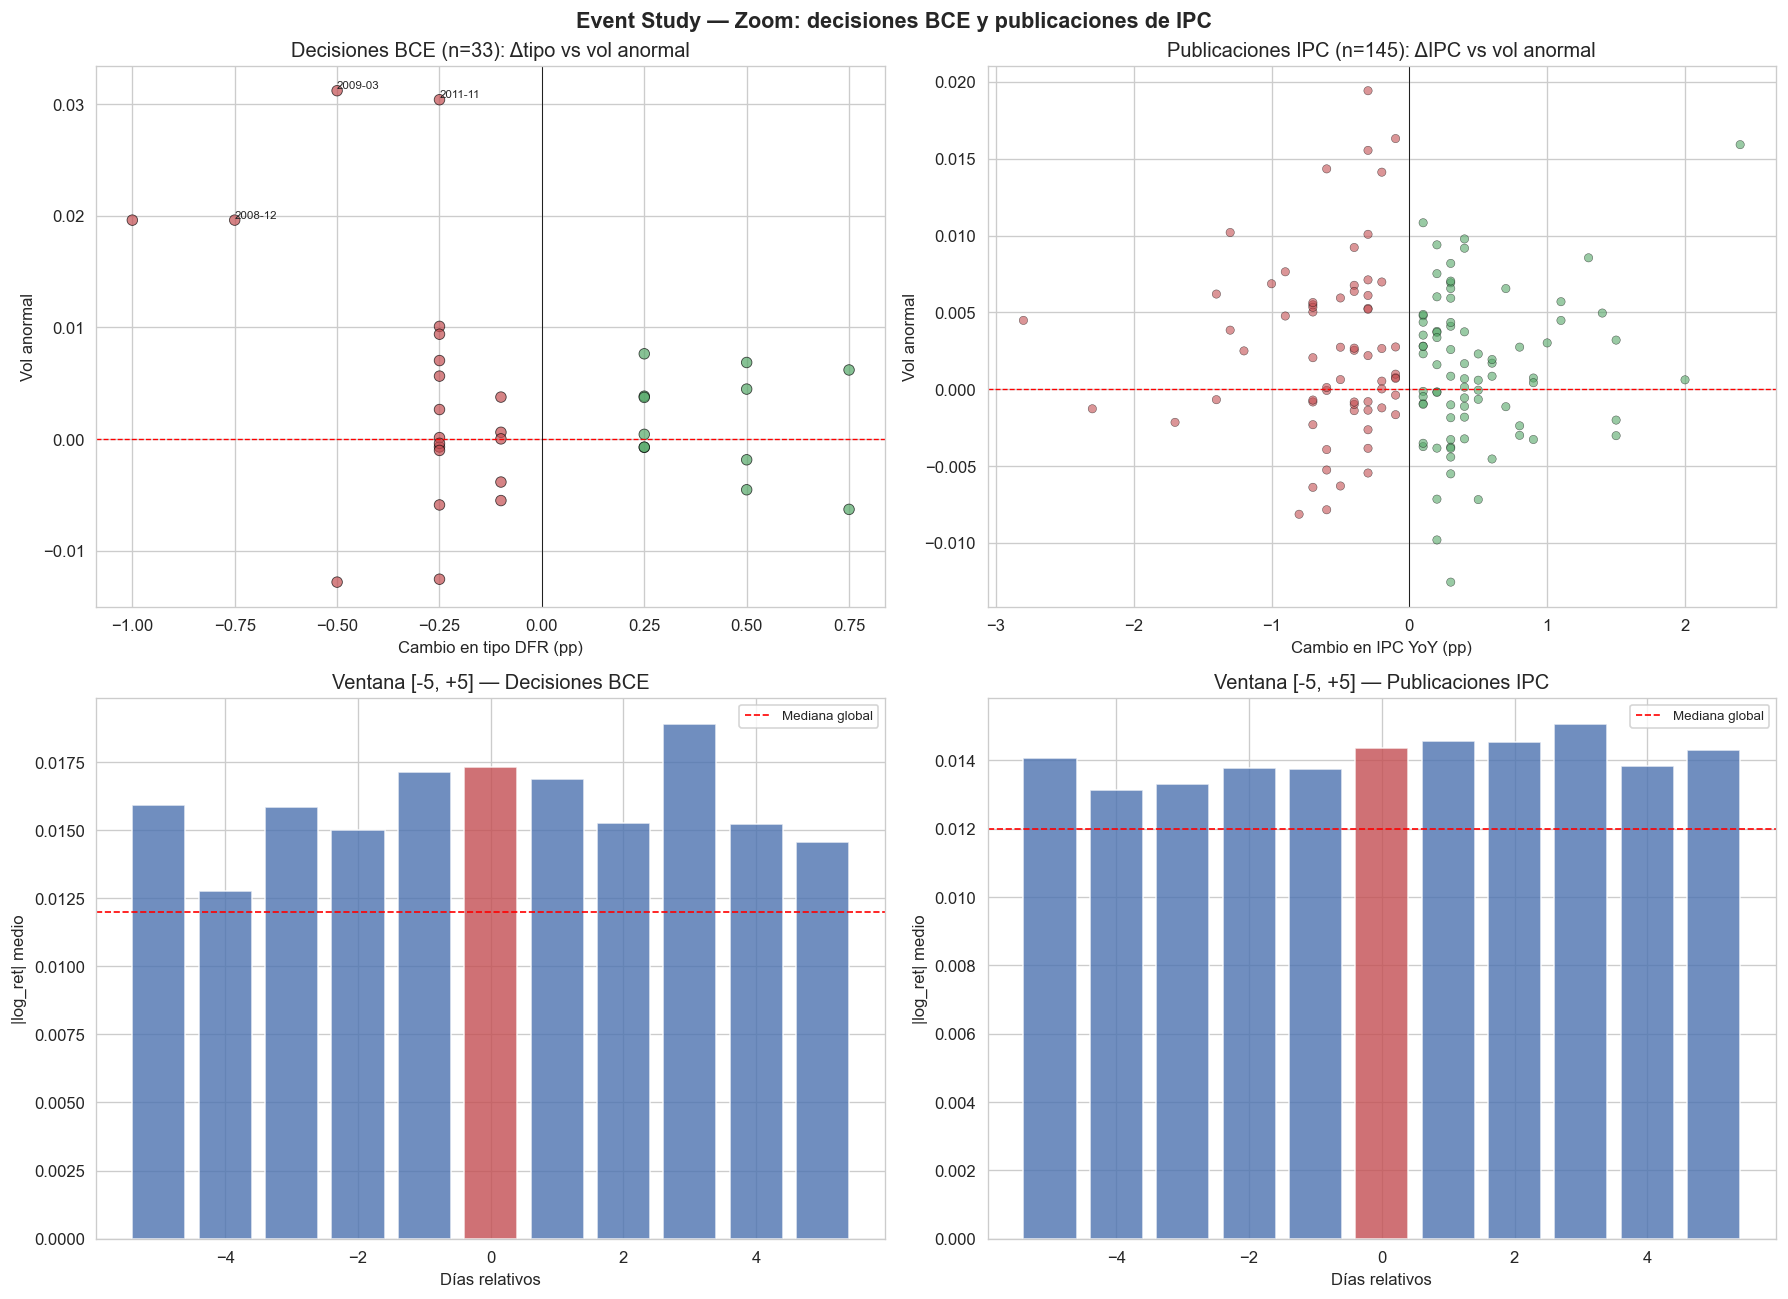

Figura guardada: 22_event_study_bce_ipc.png


In [8]:
# ── Figura 22: Zoom BCE + IPC ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Event Study — Zoom: decisiones BCE y publicaciones de IPC',
             fontsize=13, fontweight='bold')

# ── P1: Decisiones BCE — scatter delta tipo vs vol anormal ─────────────────────
ax = axes[0, 0]
bce = df_ev[df_ev['variable'] == 'tipo_dfr'].copy()
if len(bce) > 0:
    colors_bce = [COLORS[3] if d < 0 else COLORS[2] for d in bce['delta']]
    ax.scatter(bce['delta'], bce['vol_anormal'], c=colors_bce, s=40, alpha=0.7,
              edgecolors='black', lw=0.5)
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('Cambio en tipo DFR (pp)')
    ax.set_ylabel('Vol anormal')
    ax.set_title(f'Decisiones BCE (n={len(bce)}): Δtipo vs vol anormal')

    # Anotar eventos extremos
    for _, row in bce.nlargest(3, 'vol_anormal').iterrows():
        ax.annotate(row['fecha'].strftime('%Y-%m'),
                   (row['delta'], row['vol_anormal']),
                   fontsize=7, ha='left', va='bottom')

# ── P2: IPC — scatter delta IPC vs vol anormal ────────────────────────────────
ax = axes[0, 1]
ipc = df_ev[df_ev['variable'] == 'ipc_yoy'].copy()
if len(ipc) > 0:
    colors_ipc = [COLORS[3] if d < 0 else COLORS[2] for d in ipc['delta']]
    ax.scatter(ipc['delta'], ipc['vol_anormal'], c=colors_ipc, s=25, alpha=0.6,
              edgecolors='black', lw=0.3)
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('Cambio en IPC YoY (pp)')
    ax.set_ylabel('Vol anormal')
    ax.set_title(f'Publicaciones IPC (n={len(ipc)}): ΔIPC vs vol anormal')

# ── P3: Ventana temporal BCE ──────────────────────────────────────────────────
ax = axes[1, 0]
if len(bce) > 0:
    for lag in window_range:
        vals_bce = []
        for _, row in bce.iterrows():
            pos = dates_index.get_loc(row['fecha']) if row['fecha'] in dates_index else None
            if pos is not None and 0 <= pos + lag < len(dates_index):
                vals_bce.append(abs_ret_series.iloc[pos + lag])
        avg_absret_by_lag[lag] = np.mean(vals_bce) if vals_bce else np.nan

    bar_colors_bce = [COLORS[3] if l == 0 else COLORS[0] for l in lags]
    ax.bar(lags, list(avg_absret_by_lag.values()), color=bar_colors_bce, alpha=0.8)
    ax.axhline(bm_global, color='red', lw=1, ls='--', label='Mediana global')
    ax.set_title('Ventana [-5, +5] — Decisiones BCE')
    ax.set_xlabel('Días relativos')
    ax.set_ylabel('|log_ret| medio')
    ax.legend(fontsize=8)

# ── P4: Ventana temporal IPC ──────────────────────────────────────────────────
ax = axes[1, 1]
if len(ipc) > 0:
    for lag in window_range:
        vals_ipc = []
        for _, row in ipc.iterrows():
            pos = dates_index.get_loc(row['fecha']) if row['fecha'] in dates_index else None
            if pos is not None and 0 <= pos + lag < len(dates_index):
                vals_ipc.append(abs_ret_series.iloc[pos + lag])
        avg_absret_by_lag[lag] = np.mean(vals_ipc) if vals_ipc else np.nan

    bar_colors_ipc = [COLORS[3] if l == 0 else COLORS[0] for l in lags]
    ax.bar(lags, list(avg_absret_by_lag.values()), color=bar_colors_ipc, alpha=0.8)
    ax.axhline(bm_global, color='red', lw=1, ls='--', label='Mediana global')
    ax.set_title('Ventana [-5, +5] — Publicaciones IPC')
    ax.set_xlabel('Días relativos')
    ax.set_ylabel('|log_ret| medio')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '22_event_study_bce_ipc.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 22_event_study_bce_ipc.png')

## 7. Figura 23: ¿Importa la magnitud del cambio?

¿Los cambios grandes en los indicadores (sorpresas) generan más volatilidad que los cambios pequeños?

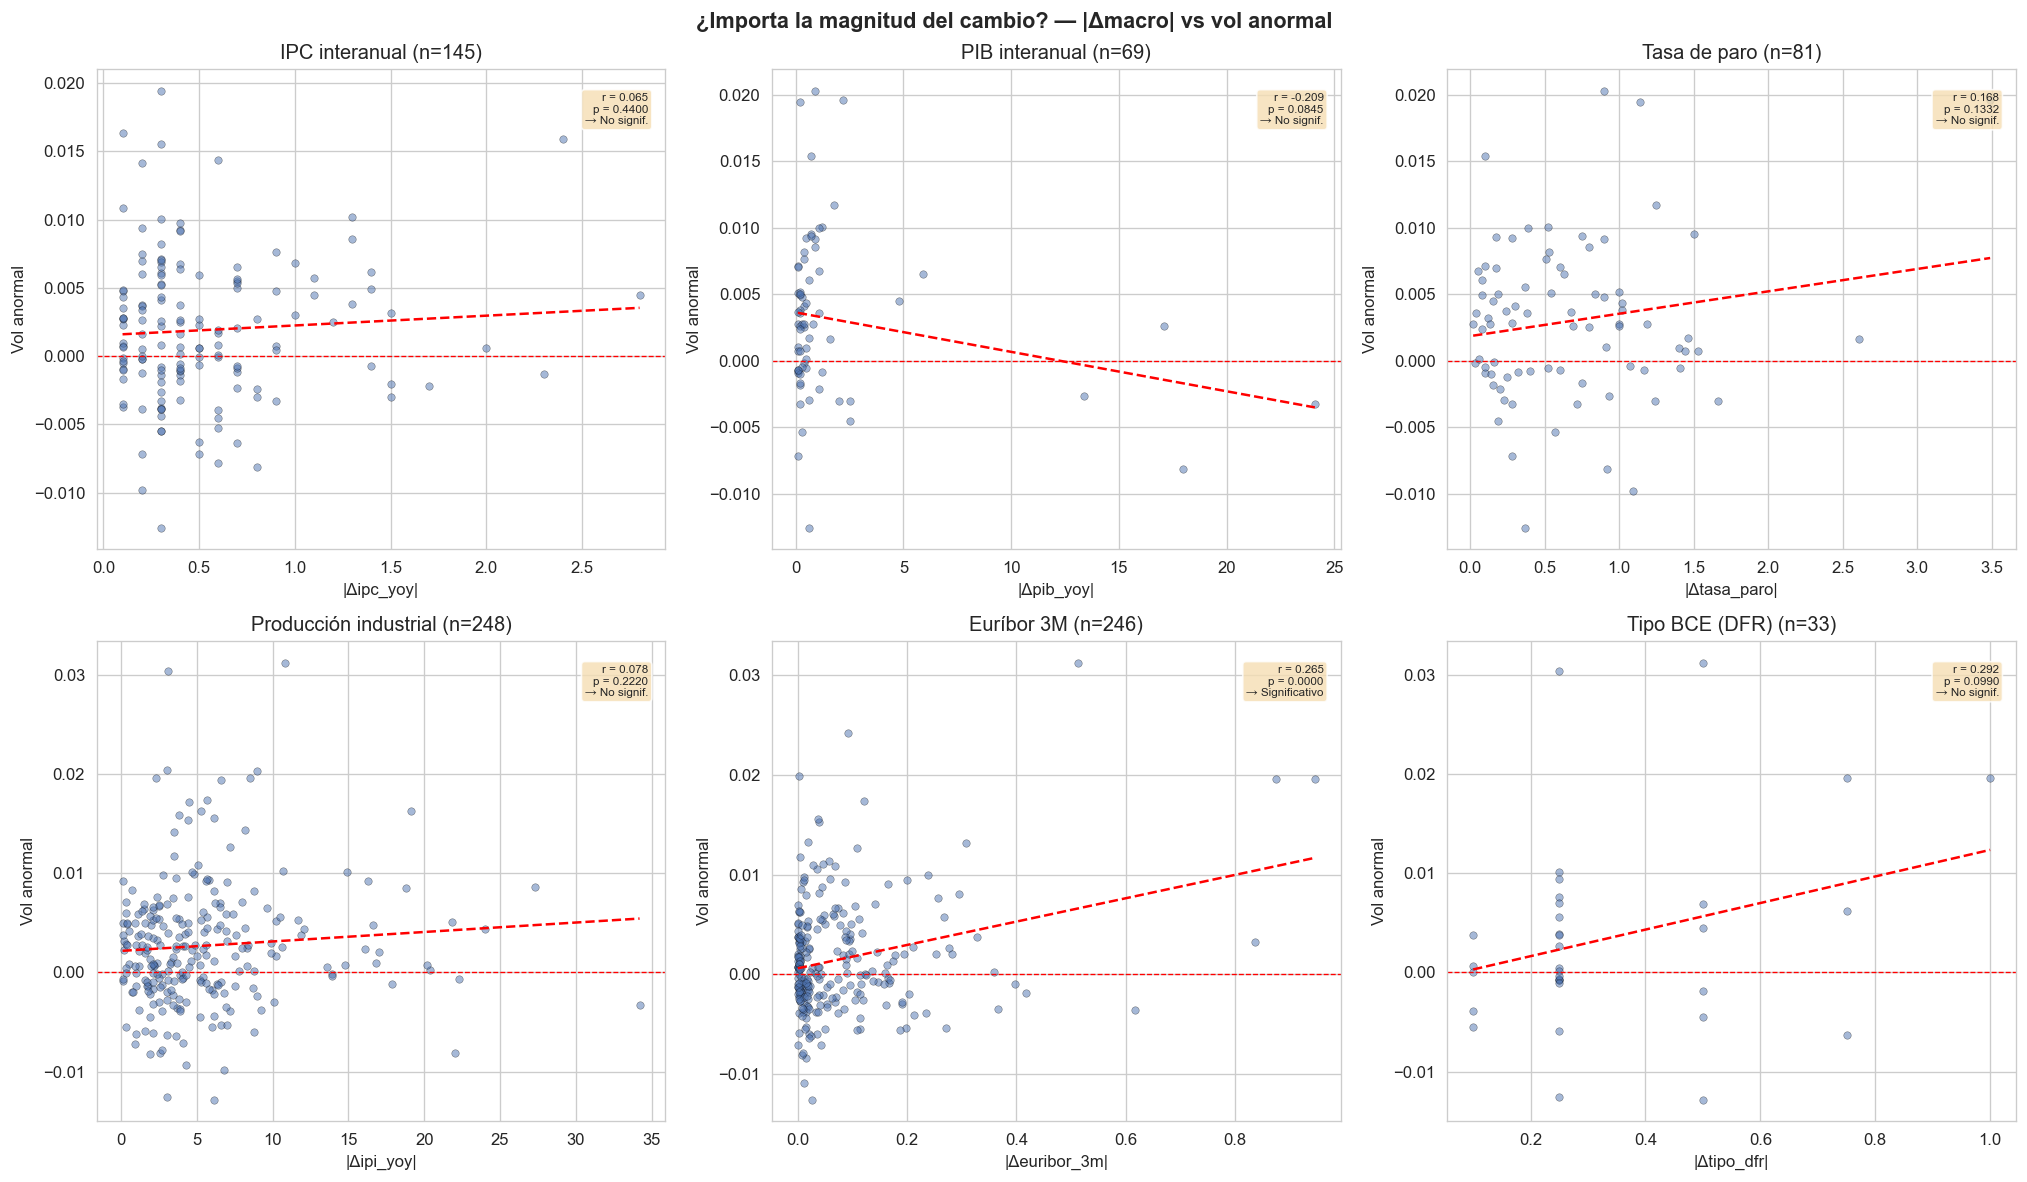

Figura guardada: 23_event_study_magnitud.png


In [9]:
# ── Figura 23: Magnitud del cambio vs vol anormal ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('¿Importa la magnitud del cambio? — |Δmacro| vs vol anormal',
             fontsize=13, fontweight='bold')

variables_plot = ['ipc_yoy', 'pib_yoy', 'tasa_paro', 'ipi_yoy', 'euribor_3m', 'tipo_dfr']

for i, col in enumerate(variables_plot):
    ax = axes[i // 3, i % 3]
    sub = df_ev[df_ev['variable'] == col].copy()
    nombre = MACRO_EVENT_COLS[col][0]

    if len(sub) < 5:
        ax.set_title(f'{nombre}\n(< 5 eventos)')
        ax.set_visible(False)
        continue

    sub['abs_delta'] = sub['delta'].abs()
    ax.scatter(sub['abs_delta'], sub['vol_anormal'], s=20, alpha=0.5,
              color=COLORS[0], edgecolors='black', lw=0.3)

    # Regresión lineal simple
    mask_valid = sub[['abs_delta', 'vol_anormal']].dropna()
    if len(mask_valid) > 5:
        slope, intercept, r, p, se = stats.linregress(
            mask_valid['abs_delta'], mask_valid['vol_anormal'])
        x_fit = np.linspace(mask_valid['abs_delta'].min(), mask_valid['abs_delta'].max(), 50)
        ax.plot(x_fit, intercept + slope * x_fit, 'r--', lw=1.5)
        ax.text(0.97, 0.95,
                f'r = {r:.3f}\np = {p:.4f}\n{"→ Significativo" if p < 0.05 else "→ No signif."}',
                transform=ax.transAxes, va='top', ha='right', fontsize=7,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.set_title(f'{nombre} (n={len(sub)})')
    ax.set_xlabel(f'|Δ{col}|')
    ax.set_ylabel('Vol anormal')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '23_event_study_magnitud.png'), bbox_inches='tight')
plt.show()
print('Figura guardada: 23_event_study_magnitud.png')

## 8. Resumen de hallazgos y conclusiones preliminares

In [10]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print('=' * 70)
print('  RESUMEN — EVENT STUDY: PUBLICACIONES MACRO Y VOLATILIDAD IBEX 35')
print('=' * 70)

print()
print('1. ¿GENERAN LAS PUBLICACIONES MACRO MÁS VOLATILIDAD?')
print(f'   Mediana |log_ret| días normales: {vol_normal.median():.5f}')
print(f'   Mediana |log_ret| días de evento: {vol_event.median():.5f}')
print(f'   Mann-Whitney p-valor (evento > normal): {mw_p:.4f}')
if mw_p < 0.05:
    print('   → SÍ: los días de publicación macro tienen significativamente más volatilidad')
else:
    print('   → NO: no hay diferencia significativa')

print()
print('2. ¿QUÉ INDICADORES GENERAN MÁS VOLATILIDAD?')
for _, row in df_res.iterrows():
    sig = '✓' if row['Significativo (5%)'] == '✓' else '✗'
    print(f'   {sig} {row["Variable"]:<30} VA media={row["Vol anormal media"]:+.5f}  '
          f'p={row["Wilcoxon p"]:.4f}  (n={int(row["N eventos"])})')

print()
print('3. ¿DIFIERE EL IMPACTO ENTRE CATEGORÍAS?')
print(f'   Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.4f}')
if kw_p < 0.05:
    print('   → SÍ: el tipo de publicación importa')
else:
    print('   → NO: no hay diferencia significativa entre categorías')

print()
print('4. ¿IMPORTA EL SIGNO?')
for _, row in df_res.iterrows():
    if pd.notna(row['VA media (Δ>0)']) and pd.notna(row['VA media (Δ<0)']):
        mayor = 'subidas' if row['VA media (Δ>0)'] > row['VA media (Δ<0)'] else 'bajadas'
        print(f'   {row["Variable"]:<30} Más vol en {mayor}: '
              f'Δ>0={row["VA media (Δ>0)"]:+.5f}  Δ<0={row["VA media (Δ<0)"]:+.5f}')

print()
print('=' * 70)

  RESUMEN — EVENT STUDY: PUBLICACIONES MACRO Y VOLATILIDAD IBEX 35

1. ¿GENERAN LAS PUBLICACIONES MACRO MÁS VOLATILIDAD?
   Mediana |log_ret| días normales: 0.01191
   Mediana |log_ret| días de evento: 0.01329
   Mann-Whitney p-valor (evento > normal): 0.0000
   → SÍ: los días de publicación macro tienen significativamente más volatilidad

2. ¿QUÉ INDICADORES GENERAN MÁS VOLATILIDAD?
   ✗ Tipo BCE (DFR)                 VA media=+0.00353  p=0.0584  (n=33)
   ✓ PIB interanual                 VA media=+0.00311  p=0.0000  (n=69)
   ✓ Tasa de paro                   VA media=+0.00295  p=0.0000  (n=81)
   ✓ IPC subyacente mensual         VA media=+0.00280  p=0.0000  (n=236)
   ✓ Producción industrial          VA media=+0.00269  p=0.0000  (n=248)
   ✓ IPC interanual                 VA media=+0.00191  p=0.0001  (n=145)
   ✓ Euríbor 3M                     VA media=+0.00152  p=0.0016  (n=246)

3. ¿DIFIERE EL IMPACTO ENTRE CATEGORÍAS?
   Kruskal-Wallis H=10.71, p=0.0047
   → SÍ: el tipo de publica

## Próximos pasos

Dependiendo de los resultados:

1. **Si hay indicadores significativos**: profundizar en esos indicadores concretos, análisis por subperiodos (pre/post crisis)
2. **Si el efecto es débil**: considerar datos de sorpresa (consenso vs dato real) en vez de simples cambios
3. **Datos adicionales posibles**:
   - Fechas exactas de publicación del INE / Eurostat (calendario estadístico)
   - Datos de consenso (Bloomberg consensus) para medir la *sorpresa* real
   - Volatilidad intradía (high-low range) como medida alternativa